In [88]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [89]:
#loading data 
df=pd.read_csv('netflix_titles.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [90]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [95]:
#data cleaning
#removing null function
df.dropna()
#spliting country
df["country"]=df["country"].str.strip()
df["country"]=df["country"].str.split(",")
df=df.explode("country")
df["country"]=df["country"].str.strip()



In [92]:
#content type description
df.groupby("type").size()

type
Movie      6131
TV Show    2676
dtype: int64

In [99]:
#popular country
df.groupby("country").size().sort_values(ascending=False).head(10)

country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
dtype: int64

In [100]:
#dates with most releases
df["release_year"].value_counts().sort_values(ascending=False).head(10)

release_year
2018    1390
2017    1276
2019    1208
2016    1155
2020    1054
2015     728
2021     657
2014     479
2013     366
2012     302
Name: count, dtype: int64

In [107]:
#when did netflix added most content
df["date_added"]=pd.to_datetime(df["date_added"], format="mixed")
df["date_added"].dt.year.value_counts().sort_values(ascending=False).head(20)

date_added
2019.0    2420
2020.0    2336
2018.0    2038
2021.0    1828
2017.0    1474
2016.0     558
2015.0     106
2014.0      34
2011.0      17
2013.0      13
2012.0       4
2009.0       2
2008.0       2
2010.0       1
Name: count, dtype: int64

In [108]:
#most popular genre
df["listed_in"].str.split(",").explode().str.strip().value_counts().head(10)

listed_in
International Movies        3508
Dramas                      3198
Comedies                    1981
International TV Shows      1464
Action & Adventure          1182
Documentaries               1116
Independent Movies          1039
TV Dramas                    851
Children & Family Movies     845
Thrillers                    806
Name: count, dtype: int64

ValueError: cannot reindex on an axis with duplicate labels

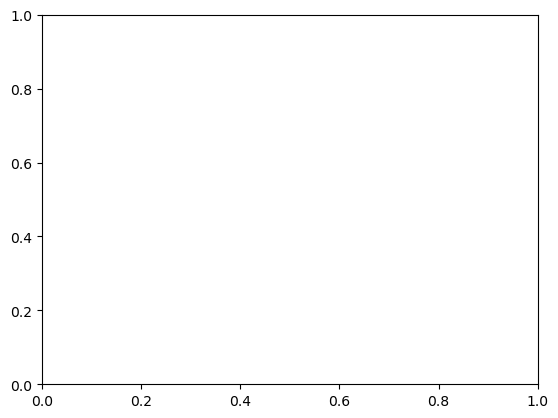